Cell 1: Google Drive Mount
python

from google.colab import drive
drive.mount('/content/drive')

Purpose: Mounts Google Drive to access data files stored in the cloud.
Why it's needed: The dataset file is too large to upload directly to Colab, so we use Google Drive as storage.
What happens: After running, you'll click an authorization link and get a mount point at /content/drive/ where your files appear.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Data Loading and Initial Inspection

Purpose: Loads the dataset and shows what the data looks like.
What it does:

Imports essential Python libraries for data science

Reads the CSV file from Google Drive

Shows the first 5 rows to understand the data structure
Output revealed: The data has 94,380 rows and 54 columns with vehicle sensor data, timestamps, and driver classes.

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/data.csv')


df.head()

,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,...,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,5.2,0.0,33,0,13.3,3,0,0,...,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,0.0,41,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,0.0,38,0,13.3,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,0.0,40,0,13.7,3,0,0,...,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1


**Cell 3: Column Removal (Feature Selection)**

Purpose: Removes irrelevant or redundant columns from the dataset.
Why remove these:

PathOrder: Just a sequence number, not useful for analysis

Duplicate columns: Like Engine_coolant_temperature.1

Highly specific engine parameters not useful for driver identification

Constant or near-constant columns
Result: Reduces from 54 to 36 columns.

In [5]:
import pandas as pd
drop_cols = [
    'PathOrder',
    'Minimum_indicated_engine_torque',
    'Maximum_indicated_engine_torque',
    'Torque_scaling_factor(standardization)',
    'Standard_Torque_Ratio',
    'Requested_spark_retard_angle_from_TCU',
    'TCU_requests_engine_torque_limit_(ETL)',
    'TCU_requested_engine_RPM_increase',
    'Fuel_Pressure',
    'Inhibition_of_engine_fuel_cut_off',
    'Engine_in_fuel_cut_off',
    'Glow_plug_control_request',
    'Activation_of_Air_compressor',
    'Engine_Idel_Target_Speed',
    'Clutch_operation_acknowledge',
    'Converter_clutch',
    'Gear_Selection',
    'Engine_coolant_temperature.1'  # Dupe of original coolant
]

# Apply drop (safe: checks existence, no error if missing)
dfc = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Quick sanity: Print shapes and var check for further prunes
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {dfc.shape}")


Original shape: (94380, 54)
Cleaned shape: (94380, 36)


In [6]:
print(len(dfc.columns))
n_col = len(dfc.columns)

36


**Cell 5: Time Window Compression Function**

Purpose: Compresses multiple time-series rows into a single summary row.
How it works: Takes all rows in a time window (e.g., 10 seconds of data) and calculates the average for each sensor.
Example: If throttle readings are [5.2, 6.1, 5.2, 4.7] over 4 seconds, returns [5.3] as the average.
Why it's useful: Reduces data volume while preserving overall patterns.

In [7]:
import numpy as np
import math
def compress(matrix):
    np_matrix = np.array(matrix)
    ls = np_matrix.mean(axis=0).tolist()
    #return [ (1 - math.exp(-abs(v)) )**2 for v in ls]
    return  ls

cell 6
Purpose: The core data preprocessing function that cleans and organizes data.
What it does:

    Removes non-numeric columns (except 'Class')

    Removes low-variance columns using coefficient of variation threshold

    Groups data into time windows (e.g., every 10 seconds)

    Compresses each window using the compress() function

    Tracks which rows belong to which driver class
    Parameters:

    df_v: Input dataframe

    vr_th: Variance ratio threshold (0.1 = keep columns with CV > 10%)

    timing: Time window size in seconds



In [8]:
def clean(df_v, vr_th , timing = 5):
    cl_df = df_v.copy()
    cols_to_drop = []

    for col_n in cl_df.columns:
        col = cl_df[col_n]

        if col_n == "Class":
            continue

        if not pd.api.types.is_numeric_dtype(col):
            cols_to_drop.append(col_n)
            continue

        if col_n == "Time(s)":
            continue

        mean_val = col.mean()
        var_val = col.var()

        if pd.isna(var_val) or var_val == 0:
            cols_to_drop.append(col_n)
            continue

        std_val = np.sqrt(var_val)

        if abs(mean_val) > 1e-10:
            cv = std_val / abs(mean_val)

            if cv < vr_th:
                cols_to_drop.append(col_n)

    print(len(cols_to_drop))
    cl_df =  cl_df.drop(columns=cols_to_drop)
    matrix = []
    positions = {}
    ligne = []
    for index, row in cl_df.iterrows():
      t = row["Time(s)"]
      if t > 0 and t % timing == 0 :
        if row["Class"] in positions:
            positions[row["Class"]].append(len(matrix))
        else:
            positions[row["Class"]] = [len(matrix)]
        matrix.append(compress(ligne))
        ligne = []
      ligne.append([val for key, val in row.items() if key not in ['Time(s)', 'Class']])



    return cl_df , matrix ,  positions

In [9]:
dfv , matrix ,  positions = clean(dfc, 0.1 ,10)
print(len(matrix) , dfv.shape[0])


3
9420 94380


In [10]:
def drivermatrixes(matrix , positions):
  matrixes = []
  for driver in positions.keys():
    matrixes.append( [ [matrix[v] ]for v in positions[driver] ])
  return matrix



## Cell 9: Feature Engineering - Statistical Feature Extraction

**What this function does:** This is the most critical step in our analysis. It transforms raw vehicle sensor data into meaningful "driving signatures" that uniquely identify each driver.

**Think of it this way:** If raw sensor data is like watching a video of someone driving, this function extracts their "driving personality" from that video.

### Step 1: Making Data Comparable (Robust Scaling)
Instead of using traditional scaling that can be thrown off by extreme values (like a sudden hard brake), we use a more resilient method. We find the middle value (median) and the typical spread (IQR - middle 50% range) for each sensor, then adjust all values relative to these. This makes the data from different sensors and different drivers comparable on the same scale.

### Step 2: Weighting What Matters (Feature Importance)
Not all sensors are equally important for identifying drivers. A sensor that barely changes (like engine coolant temperature once warmed up) tells us less than one that varies a lot (like steering wheel angle). We automatically give more weight to sensors that show more variation across time, as these are likely more informative for distinguishing driving styles.

### Step 3: Extracting the "DNA" of Driving
For each 10-second driving window, we extract **6 key characteristics**:

**First 3 features (Current State):**
1. **Average Behavior** - What's the typical driving style in this window?
2. **Consistency** - How steady or variable is the driving?
3. **Asymmetry** - Does the driver tend to favor certain actions (like more acceleration than braking)?

**Next 3 features (Dynamic Changes):**
4. **Change Magnitude** - How much does driving behavior change from the previous window?
5. **Change Consistency** - Are changes smooth or abrupt?
6. **Change Direction** - Do changes tend to go more in one direction than another?

**Why these 6 features work:**  
The first three capture "what" the driver is doing (their static style), while the last three capture "how" they do it (their dynamic adjustments). Together, they form a complete fingerprint of driving behavior that's unique to each person, much like handwriting analysis.

**Output:** Each 10-second window of driving (with 36 different sensor readings) gets reduced to just 6 numbers. These 6 numbers contain the essence of the driving behavior in that window and are perfect for training machine learning models to recognize drivers.

In [11]:
import numpy as np
from scipy.stats import skew
def scale_vec(mat):
  mat = np.array(mat)
  n = len(mat[0])
  m = len(mat)
  scaled_mat = []
  variances = []
  weights = []
  def getrange(x):
    return [  mat[i][x] for i in range(m) ]
  for i in range(n):
    observations = getrange(i)
    median = np.median(observations)
    q1 = np.percentile(observations, 25)
    q3 = np.percentile(observations, 75)
    iqr = q3 - q1
    observations = (observations - median)/(0.001 +iqr)
    weights.append(1 / (np.var(observations) +  1e-10 ) )
    scaled_mat.append(list(observations))
  deltas = []
  sum_weights = sum(weights)
  weights= [ weights[i] /sum_weights  for i in range(n)]
  scaled = []
  for j in range(m - 1 ):
    observations = [ ( scaled_mat[i][j+1]-  scaled_mat[i][j]) * weights[i]  for i in range(n) ]
    obs = [ scaled_mat[i][j] * weights[i] for i in range(n)]
    scaled.append(obs)
    deltas.append(observations)

  #vectorize
  vecs = []
  def getInt(row):
    row = np.array(row)
    return np.mean(row), np.std(row) , skew(row)
  print(len(scaled_mat))
  for i in range(m-1):
    mx , stx , skx= getInt(scaled[i])
    my , sty , sky= getInt(deltas[i])
    vecs.append([ mx , stx , skx , my , sty , sky])
  return vecs






In [12]:
vecs = scale_vec(matrix)

31


In [17]:
def kmeans_sixDimensions(features, max_k=15, method='elbow'):
    import numpy as np
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import silhouette_score

    X = np.array(features)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    k_range = range(2, min(max_k + 1, len(X_scaled) - 1))

    inertias = []
    silhouettes = []
    models = []

    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X_scaled)
        labels = km.labels_

        inertias.append(km.inertia_)

        if len(set(labels)) > 1:
            silhouettes.append(silhouette_score(X_scaled, labels))
        else:
            silhouettes.append(np.nan)

        models.append(km)

    if method == 'elbow':
        diff1 = np.diff(inertias)
        diff2 = np.diff(diff1)
        if len(diff2) > 0:
            elbow_idx = np.argmax(np.abs(diff2)) + 2
            optimal_k = k_range[elbow_idx] if elbow_idx < len(k_range) else k_range[-1]
        else:
            optimal_k = k_range[np.argmax(np.abs(diff1))]
    else:  # silhouette
        valid_idx = ~np.isnan(silhouettes)
        if np.any(valid_idx):
            optimal_k = k_range[np.nanargmax(silhouettes)]
        else:
            optimal_k = k_range[len(k_range)//2]

    best_model = models[optimal_k - 2]
    labels = best_model.labels_

    cluster_counts = {}
    for label in np.unique(labels):
        cluster_counts[int(label)] = int(np.sum(labels == label))

    return {
        'labels': labels,
        'optimal_k': int(optimal_k),
        'cluster_counts': cluster_counts,
        'total_samples': len(labels),
        'main_clusters': len(cluster_counts)
    }

In [18]:
kmeans_sixDimensions(vecs)

{'labels': array([0, 1, 3, ..., 2, 2, 0], dtype=int32),
 'optimal_k': 4,
 'cluster_counts': {0: 1252, 1: 3070, 2: 3172, 3: 1925},
 'total_samples': 9419,
 'main_clusters': 4}

In [19]:
def visualize_all_2d_combinations(feature_vectors, cluster_labels=None,
                                  feature_names=None, sample_size=500,
                                  random_state=42, figsize=(20, 15)):
    """
    Visualize all possible 2D combinations of the 6-dimensional feature space.

    Parameters:
    -----------
    feature_vectors : array-like, shape (n_samples, 6)
        The 6-dimensional feature vectors
    cluster_labels : array-like, shape (n_samples,), optional
        Cluster labels (KMeans, DBSCAN, or driver IDs)
    feature_names : list of str, optional
        Feature names (default provided)
    sample_size : int, optional
        Number of points to sample
    random_state : int, optional
        Random seed
    figsize : tuple, optional
        Figure size

    Returns:
    --------
    fig, axes
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import cm
    from itertools import combinations
    from scipy import stats
    import warnings
    warnings.filterwarnings('ignore')

    X = np.array(feature_vectors)
    n_features = X.shape[1]

    if len(X) > sample_size:
        np.random.seed(random_state)
        indices = np.random.choice(len(X), sample_size, replace=False)
        X_sampled = X[indices]
        labels_sampled = np.array(cluster_labels)[indices] if cluster_labels is not None else None
    else:
        X_sampled = X
        labels_sampled = cluster_labels

    if feature_names is None:
        feature_names = ['Mean_State', 'Std_State', 'Skew_State',
                         'Mean_Change', 'Std_Change', 'Skew_Change']

    combos = list(combinations(range(n_features), 2))

    fig, axes = plt.subplots(3, 5, figsize=figsize)
    axes = axes.flatten()

    if labels_sampled is not None:
        unique_labels = np.unique(labels_sampled)
        n_clusters = len(unique_labels)
        colors = cm.tab20c(np.linspace(0, 1, n_clusters))
        if -1 in unique_labels:
            noise_idx = np.where(unique_labels == -1)[0][0]
            colors[noise_idx] = [0.5, 0.5, 0.5, 1.0]
    else:
        colors = ['steelblue']
        unique_labels = None

    for idx, (i, j) in enumerate(combos):
        ax = axes[idx]
        x = X_sampled[:, i]
        y = X_sampled[:, j]

        corr, p_value = stats.pearsonr(x, y) if len(x) > 2 else (0, 1)

        if labels_sampled is not None:
            for c_idx, label in enumerate(unique_labels):
                mask = labels_sampled == label
                color = colors[c_idx]
                lab = None
                if idx == 0:
                    lab = 'Noise' if label == -1 else f'Cluster {label}'

                if label == -1:
                    ax.scatter(x[mask], y[mask], c=[color], s=20, alpha=0.3,
                               marker='x', label=lab)
                else:
                    ax.scatter(x[mask], y[mask], c=[color], s=30, alpha=0.6,
                               label=lab)
        else:
            ax.scatter(x, y, c=colors[0], s=30, alpha=0.6)

        ax.set_xlabel(feature_names[i], fontsize=9)
        ax.set_ylabel(feature_names[j], fontsize=9)

        sig_star = "*" if p_value < 0.05 else ""
        title_color = 'red' if abs(corr) > 0.5 else ('orange' if abs(corr) > 0.3 else 'black')
        ax.set_title(f'r = {corr:.2f}{sig_star}', fontsize=10, color=title_color, pad=5)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    for idx in range(len(combos), len(axes)):
        axes[idx].axis('off')

    fig.suptitle('2D Feature Space Analysis - All 15 Pairwise Combinations\n' +
                 ('Color-coded by Driver Clusters' if cluster_labels is not None else 'All Driving Patterns'),
                 fontsize=14, fontweight='bold', y=1.02)

    if unique_labels is not None and len(unique_labels) <= 10:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    plt.tight_layout()
    return fig, axes


def analyze_feature_correlations(feature_vectors, feature_names=None,
                                 cluster_labels=None, threshold=0.5):
    """
    Analyze and visualize correlation matrix of all 6 features.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    X = np.array(feature_vectors)

    if feature_names is None:
        feature_names = ['Mean_State', 'Std_State', 'Skew_State',
                         'Mean_Change', 'Std_Change', 'Skew_Change']

    df = pd.DataFrame(X, columns=feature_names)

    if cluster_labels is not None:
        df['Cluster'] = cluster_labels
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)

        fig, axes = plt.subplots(1, n_clusters + 1, figsize=(5*(n_clusters + 1), 4))

        corr_matrix = df.drop(columns=['Cluster']).corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5, ax=axes[0],
                    cbar_kws={"shrink": 0.8})
        axes[0].set_title('Overall Correlation')

        for idx, cluster in enumerate(unique_clusters):
            name = 'Noise' if cluster == -1 else f'Cluster {cluster}'
            cluster_data = df[df['Cluster'] == cluster].drop(columns=['Cluster'])

            if len(cluster_data) > 2:
                cluster_corr = cluster_data.corr()
                sns.heatmap(cluster_corr, annot=True, cmap='coolwarm', center=0,
                            square=True, linewidths=0.5, ax=axes[idx + 1],
                            cbar_kws={"shrink": 0.8})
                axes[idx + 1].set_title(f'{name}\n(n={len(cluster_data)})')
            else:
                axes[idx + 1].text(0.5, 0.5, 'Insufficient\nData',
                                  ha='center', va='center')
                axes[idx + 1].set_title(f'{name}\n(n={len(cluster_data)})')
                axes[idx + 1].set_xticks([])
                axes[idx + 1].set_yticks([])

        plt.suptitle('Feature Correlation Analysis by Cluster', fontsize=14, fontweight='bold')
    else:
        corr_matrix = df.corr()
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5, ax=ax,
                    cbar_kws={"shrink": 0.8})
        ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix)):
                if abs(corr_matrix.iloc[i, j]) > threshold and i != j:
                    ax.text(j + 0.5, i + 0.5, '★',
                            ha='center', va='center', fontsize=14,
                            color='gold', fontweight='bold')

    plt.tight_layout()
    return corr_matrix


def identify_separating_features(feature_vectors, cluster_labels,
                                 feature_names=None, top_n=3):
    """
    Identify feature combinations that best separate clusters.
    """

    import numpy as np
    from itertools import combinations
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import cross_val_score
    import matplotlib.pyplot as plt

    X = np.array(feature_vectors)
    y = np.array(cluster_labels)

    mask = y != -1
    X_clean = X[mask] if np.any(mask) else X
    y_clean = y[mask] if np.any(mask) else y

    if feature_names is None:
        feature_names = ['Mean_State', 'Std_State', 'Skew_State',
                         'Mean_Change', 'Std_Change', 'Skew_Change']

    combos = list(combinations(range(X.shape[1]), 2))
    separation_scores = []

    for i, j in combos:
        X_subset = X_clean[:, [i, j]]
        if len(np.unique(y_clean)) > 1 and len(X_subset) > len(np.unique(y_clean)):
            try:
                lda = LinearDiscriminantAnalysis()
                scores = cross_val_score(lda, X_subset, y_clean, cv=min(5, len(np.unique(y_clean))))
                separation_scores.append(np.mean(scores))
            except:
                separation_scores.append(0)
        else:
            separation_scores.append(0)

    sorted_idx = np.argsort(separation_scores)[::-1]
    best_combinations = []
    best_scores = []

    print("=" * 70)
    print("TOP FEATURE COMBINATIONS FOR CLUSTER SEPARATION")
    print("=" * 70)
    print("\nRank | Features (X vs Y)       | Separation Score | Interpretation")
    print("-" * 70)

    for rank, idx in enumerate(sorted_idx[:top_n]):
        i, j = combos[idx]
        score = separation_scores[idx]
        best_combinations.append((i, j))
        best_scores.append(score)

        interp = ("Excellent" if score > 0.8 else
                  "Good" if score > 0.6 else
                  "Moderate" if score > 0.4 else
                  "Poor")

        print(f"{rank+1:^4} | {feature_names[i]:>10} vs {feature_names[j]:<10} | {score:^16.3f} | {interp}")

    print("-" * 70)

    fig, axes = plt.subplots(1, min(top_n, 3), figsize=(4*min(top_n, 3), 4))
    if top_n == 1:
        axes = [axes]

    unique_labels = np.unique(y)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for ax_idx, combo_idx in enumerate(sorted_idx[:top_n]):
        i, j = combos[combo_idx]
        score = separation_scores[combo_idx]
        ax = axes[ax_idx]

        for l_idx, label in enumerate(unique_labels):
            mask = y == label
            color = colors[l_idx]
            if label == -1:
                ax.scatter(X[mask, i], X[mask, j], c=[color], s=20, alpha=0.3,
                           marker='x', label='Noise')
            else:
                ax.scatter(X[mask, i], X[mask, j], c=[color], s=30, alpha=0.6,
                           label=f'Cluster {label}')

        ax.set_xlabel(feature_names[i])
        ax.set_ylabel(feature_names[j])
        ax.set_title(f'Rank {ax_idx+1}: Score = {score:.3f}', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')

    plt.suptitle(f'Top {min(top_n, 3)} Feature Combinations for Driver Separation',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()

    return best_combinations, best_scores



(<Figure size 2000x1500 with 15 Axes>,
 array([<Axes: title={'center': 'r = 0.17*'}, xlabel='Mean_State', ylabel='Std_State'>,
        <Axes: title={'center': 'r = -0.16*'}, xlabel='Mean_State', ylabel='Skew_State'>,
        <Axes: title={'center': 'r = -0.32*'}, xlabel='Mean_State', ylabel='Mean_Change'>,
        <Axes: title={'center': 'r = 0.28*'}, xlabel='Mean_State', ylabel='Std_Change'>,
        <Axes: title={'center': 'r = -0.05'}, xlabel='Mean_State', ylabel='Skew_Change'>,
        <Axes: title={'center': 'r = 0.42*'}, xlabel='Std_State', ylabel='Skew_State'>,
        <Axes: title={'center': 'r = -0.02'}, xlabel='Std_State', ylabel='Mean_Change'>,
        <Axes: title={'center': 'r = 0.09*'}, xlabel='Std_State', ylabel='Std_Change'>,
        <Axes: title={'center': 'r = -0.09*'}, xlabel='Std_State', ylabel='Skew_Change'>,
        <Axes: title={'center': 'r = -0.01'}, xlabel='Skew_State', ylabel='Mean_Change'>,
        <Axes: title={'center': 'r = -0.04'}, xlabel='Skew_State', y

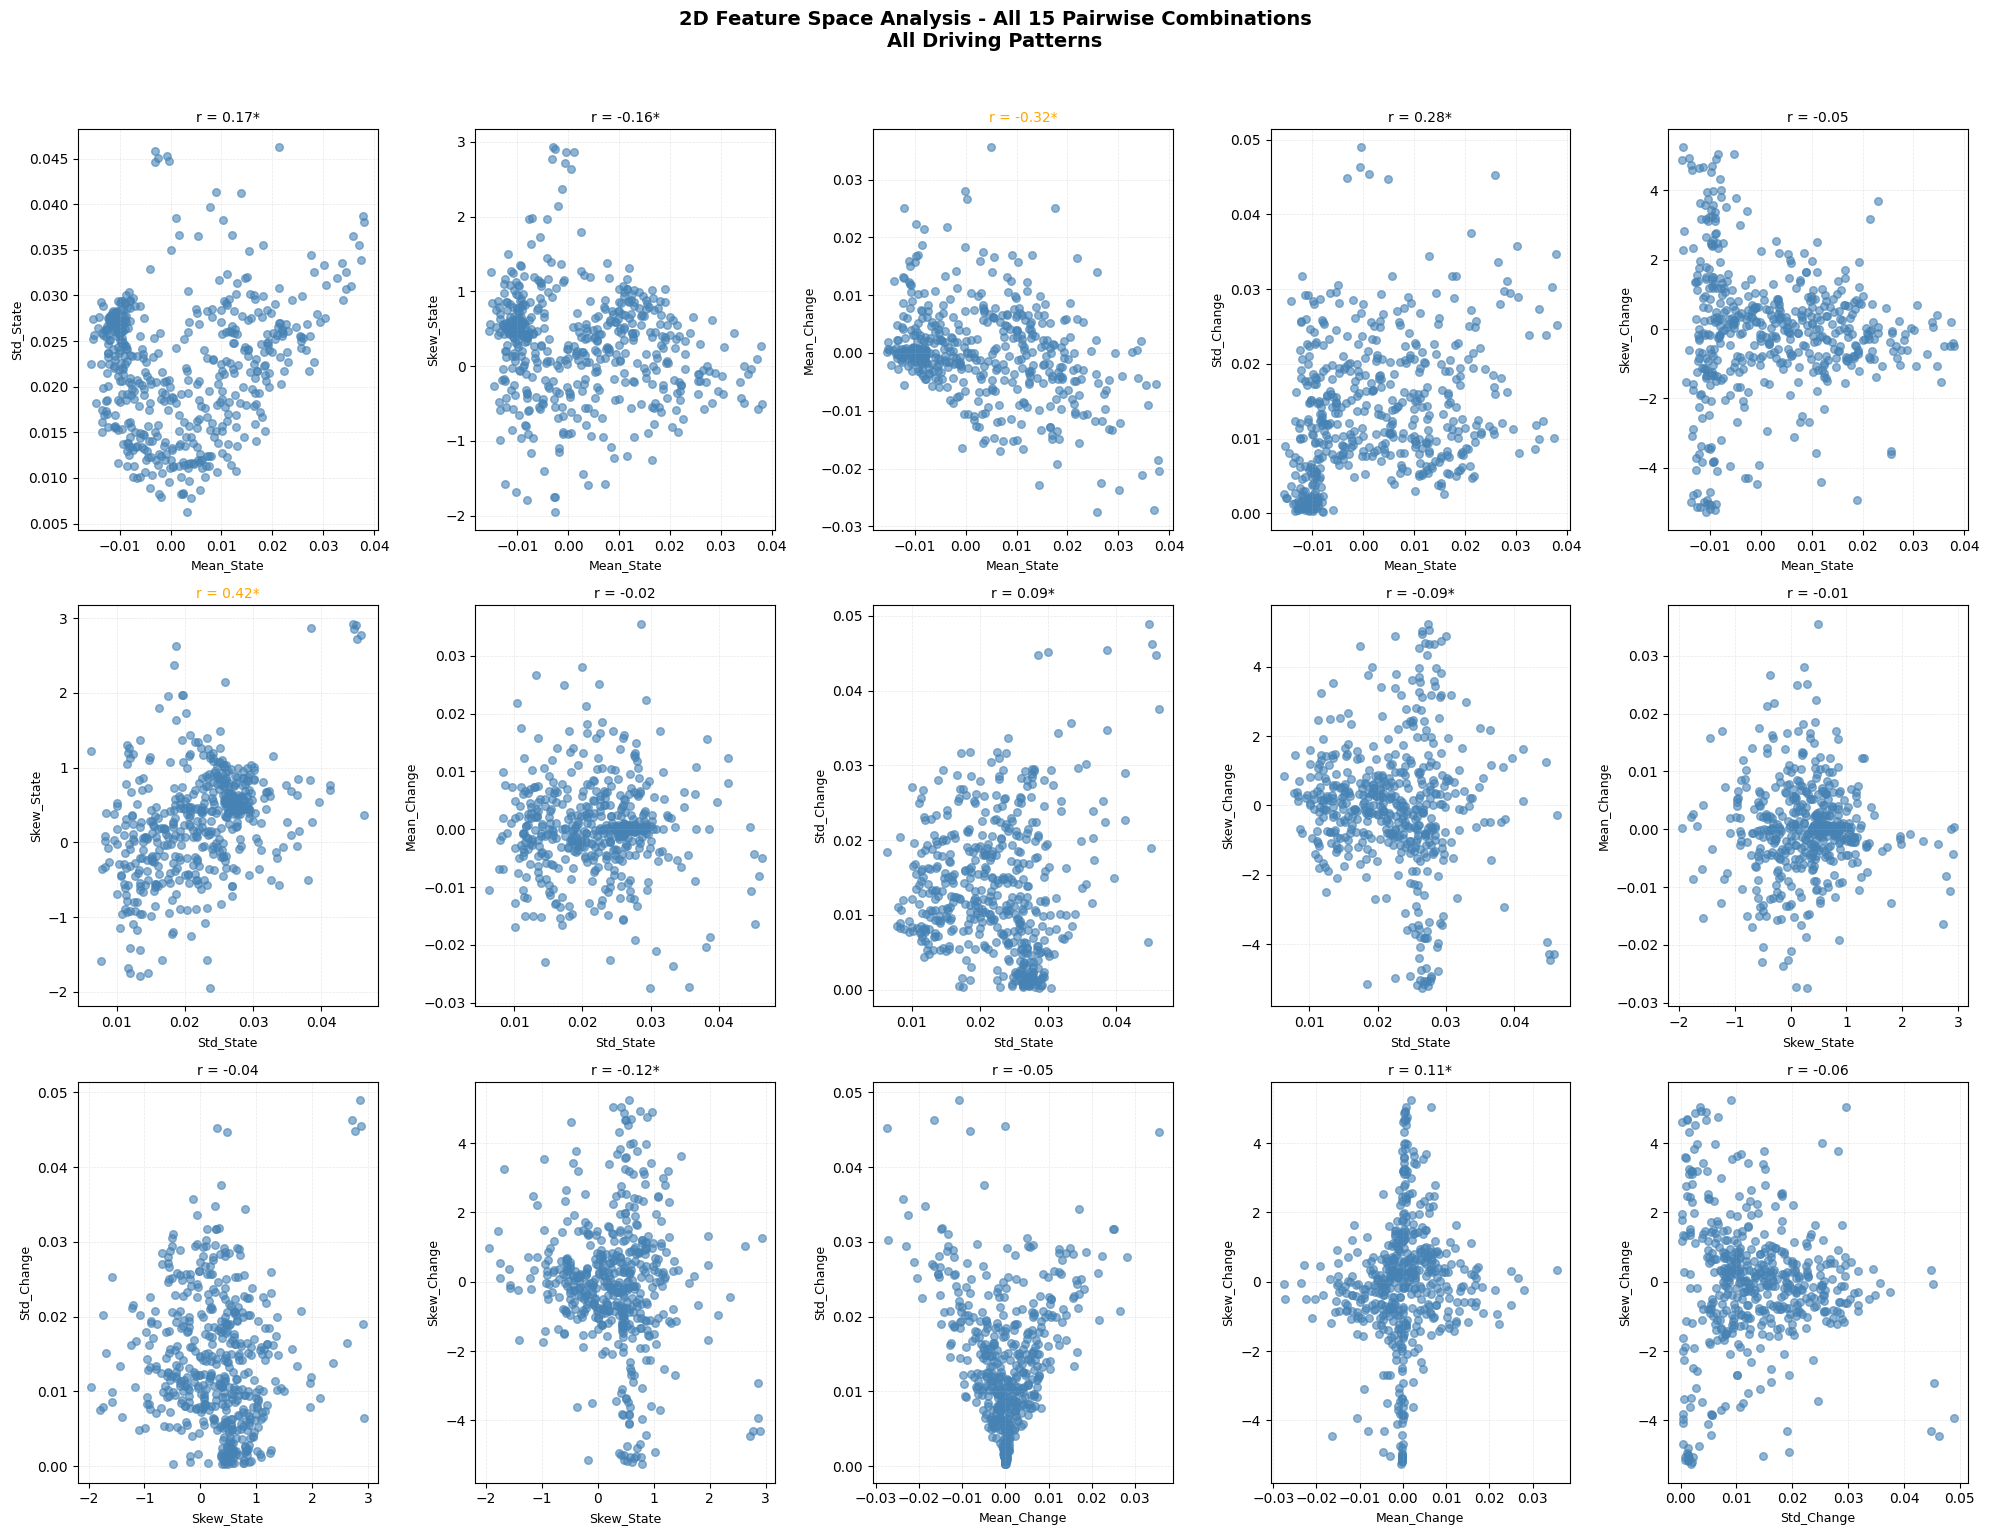

In [20]:
visualize_all_2d_combinations(vecs)